In [2]:
# pandas / matplotlib / seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# train
train = pd.read_csv('data/train.csv')
# test
test = pd.read_csv('data/test.csv')
# gender
gender = pd.read_csv('data/gender_submission.csv')

In [4]:
# tarin.info()
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# 결측치 확인
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
!pip install missingno
import missingno as msno

Defaulting to user installation because normal site-packages is not writeable


<Axes: >

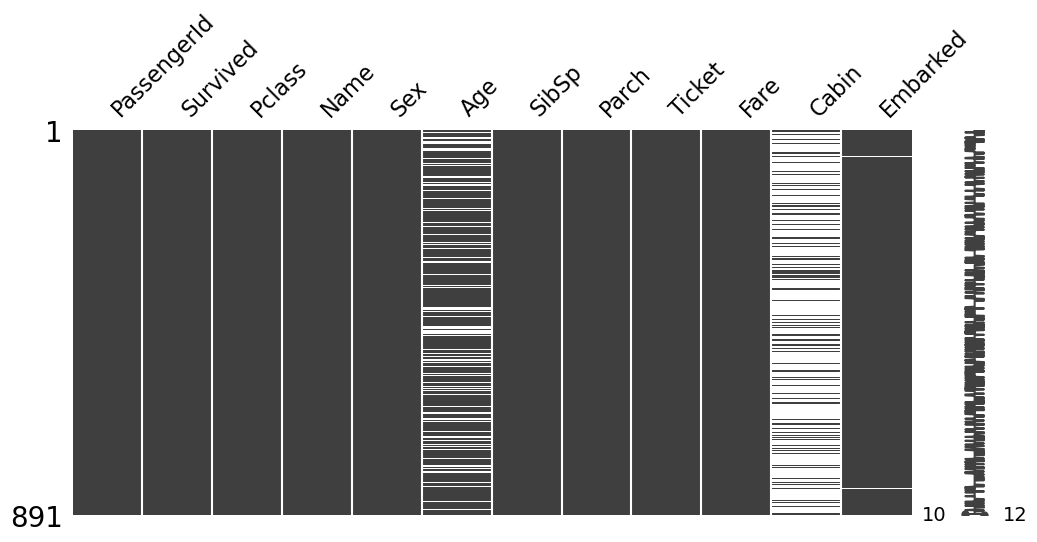

In [7]:
msno.matrix(train, figsize=(12,5))

### 생존

<Axes: ylabel='count'>

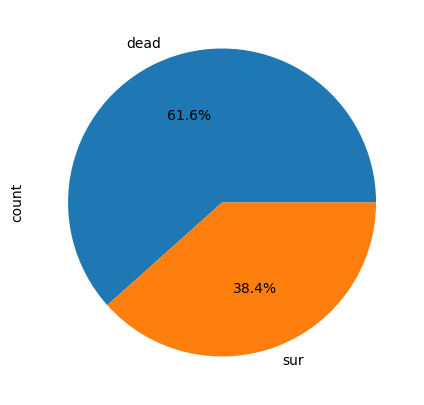

In [9]:
# 생존비율 확인
# train에서 생존과 사망이 어떤 비율로 있는지 확인
# 생존에 관련된 데이터은 어디에 담겨있나요?
# value_counts : 컬럼에 있는 유니크한 내용에 수를 카운트 하는 함수
# 여기서는 뭐랑 뭐만 카운트가 될까요?? / dead survived만 카운트가 되겠죠??
train['Survived'].value_counts()

plt.figure(figsize=(8,5))
labels = ['dead','sur']
# 파이 차트를 사용
train['Survived'].value_counts().plot.pie(autopct='%1.1f%%',
                                         labels = labels)

### 이 그래프를 통해 알 수 있는 사실은 사망 비율은 약 61% 생존 비율은 약 39%로 사망한 탑승 객의 수가 더 많은 것이 확인된다

### 성별

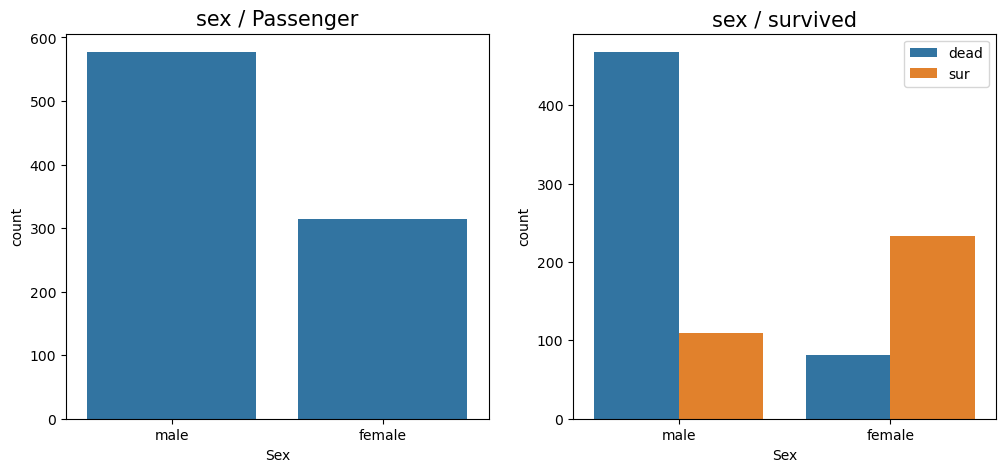

In [12]:
# fit, axes : 변수 2개를 지정한 이유 -> 행과 열에 대한 내용입니다
# 그럼 지금 이 subplots의 의미는 한 행에 박스 2개 만들겠다는 의미겠죠??
fit, axes = plt.subplots(1,2,figsize=(12,5))
# 첫번째 박스에 관련된 내용
# 인덱스 번호 0 처음을 의미
# 항상 시각화를 할 때 맨 처음에 들어오는 데이터는 어떤 축이라고 했어요??
# X축을 먼저 지정한다
axes[0].set_title('sex / Passenger', size = 15)
sns.countplot(x = 'Sex', data = train, ax = axes[0])

# axes[1] 두번째 박스
axes[1].set_title('sex / survived', size = 15)
sns.countplot(x='Sex', hue = 'Survived', data = train, ax = axes[1])
axes[1].legend(labels = ['dead','sur'])

### 이 시각화를 통해 알 수 있는 사실은 타이타닉 호에 남성이 더 많이 타 있었지만 여성이 더 많이 살았다 

,Survived
Sex,
female,0.742038
male,0.188908


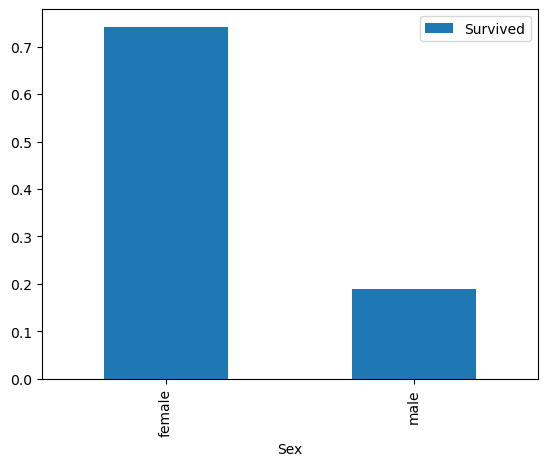

In [14]:
# 성별에 따른 생존률도 한번 보도록 하겠습니다
# 대괄호 2개 입니다
# 성별로 그룹화 시켜주겠다
sur = train[['Sex','Survived']].groupby('Sex').mean().plot.bar()
train[['Sex','Survived']].groupby('Sex').mean()

### 여성의 생존률은 약 74% 남성의 생존률은 약 18%로 여성의 생존률이 압도적으로 높은걸 확인할 수 있다
- 남성보다 여성을 먼저 구조한 것으로 보인다

# 티켓 클라스(pclass)

In [17]:
# 티켓 클래스 별로 어떤 생존률을 보이고 있는지 확인
train[['Pclass','Survived']].groupby('Pclass').mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


### 1등석의 생존률은 약 62% 2등석의 생존률은 약 47% 3등석의 생존률은 약 24%로 확인된다
- 그렇다는 말은 3등석 탑승객들이 많이 사망했다라고 생각해도 되지 않을까??

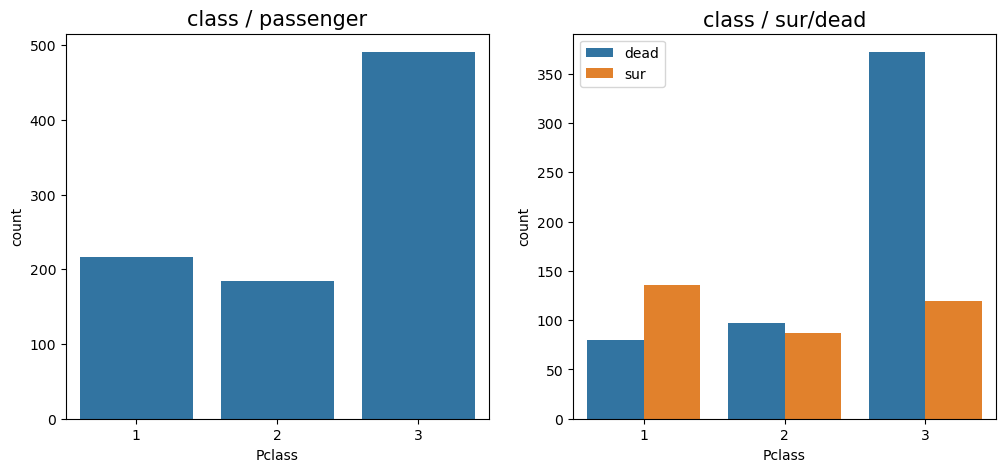

In [19]:
# 시각화해서 살펴보자
fig, axes = plt.subplots(1,2,figsize=(12,5))

# 첫번째 박스
axes[0].set_title('class / passenger', size = 15)
sns.countplot(x = 'Pclass', data = train, ax = axes[0])

# 두번째 박스
axes[1].set_title('class / sur/dead', size = 15)
sns.countplot(x = 'Pclass', data = train,hue = 'Survived', ax = axes[1])
axes[1].legend(labels = ['dead','sur'])

### 3등석 탑승객이 가장 많고 3등석 탑승객의 사망 인원수 또한 가장 많을 걸 확인할 수 있다 상대적으로 1등석 탑승객들은 많이 살아남은 것으로 보인다

Text(0.5, 1.0, 'class / sur')

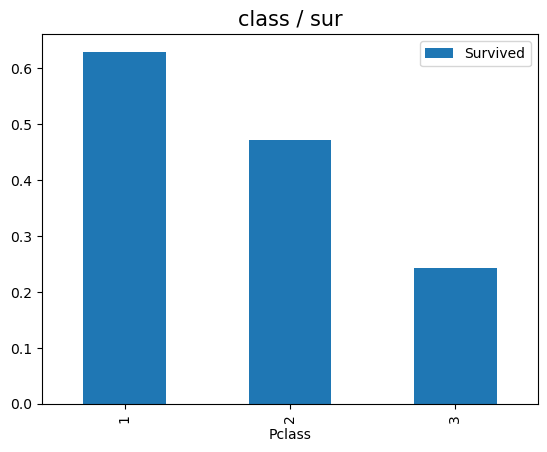

In [21]:
# 클래스별 생존률을 확인해보면
sur = train[['Pclass','Survived']].groupby(['Pclass']).mean().plot.bar()
sur.set_title('class / sur', size = 15)

### 1등석이 가장 높은 생존률을 보이고 3등석이 가장 낮은 생존률을 보인다 class는 생존 유무에 어느 정도 영향을 미치는 것으로 보인다

### 나이(age)

In [24]:
# 수치적으로 어떻게 분포되었는지 확인
train['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

C:\Users\User\AppData\Local\Temp\ipykernel_11104\3216510898.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'], bins = 25)


<Axes: xlabel='Age', ylabel='Density'>

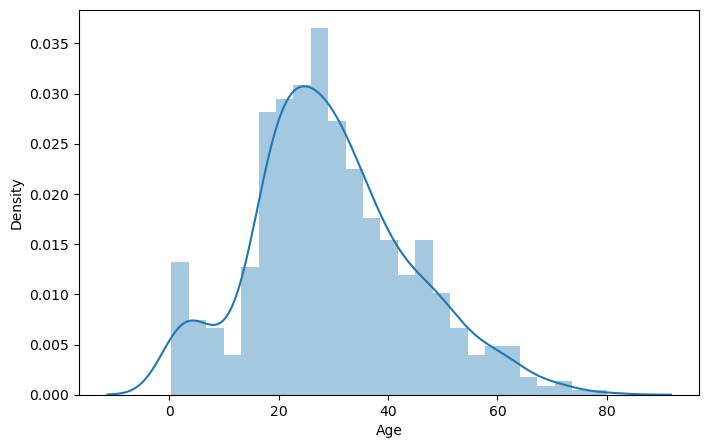

In [25]:
# figsize = 박스 그래프가 나오는 크기의 사이즈 지정
# 사용자가 지정하므로 정확한 정답이 없다
# distplot 히스토그램 + 곡선그래프
plt.figure(figsize=(8,5))
sns.distplot(train['Age'], bins = 25)

### 탑승객의 나이는 주로 10 or 20 ~ 40 or 50 까지 분포하고 있다

C:\Users\User\AppData\Local\Temp\ipykernel_11104\628116769.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sur['Age'], bins = 25, hist = False)
C:\Users\User\AppData\Local\Temp\ipykernel_11104\628116769.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dead['Age'], bins =

<Axes: xlabel='Age', ylabel='Density'>

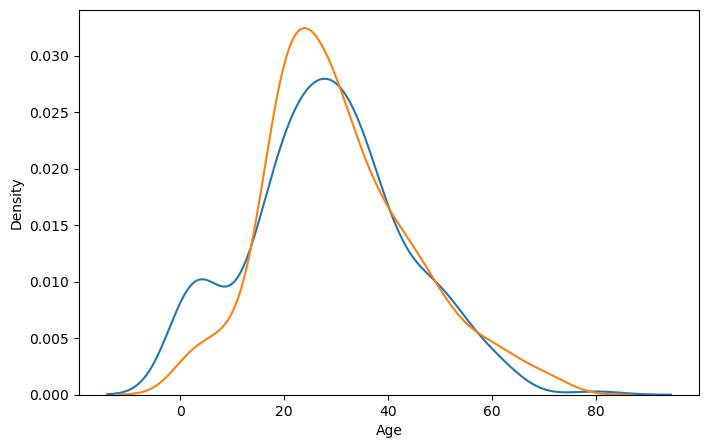

In [27]:
# 나이가 생존여부에 영향을 끼치는지 확인하기 위해
# 생존/사망 탑승객을 나눠보겠다

sur = train[train['Survived'] == 1]
dead = train[train['Survived'] == 0]

plt.figure(figsize=(8,5))
sns.distplot(sur['Age'], bins = 25, hist = False)
sns.distplot(dead['Age'], bins = 25, hist = False)

### 어린 나이의 탑승객들의 생존률이 비교적 높고 20~30세의 죽음이 많았다

 SibSp -> 함께 탑승한 형제자매, 배우자의 수 총합 <br>
 Parch -> 함께 탑승한 부모, 자녀 수 총합

In [30]:
# 함께 탑승한 형제나 배우자 또는 부모와 생존이 관련있는지 확인
# SibSp / Parch 가족의 수와 비슷하므로 비슷한 경향을 것 같다

<Axes: title={'center': 'Parch / survived'}, xlabel='Parch', ylabel='count'>

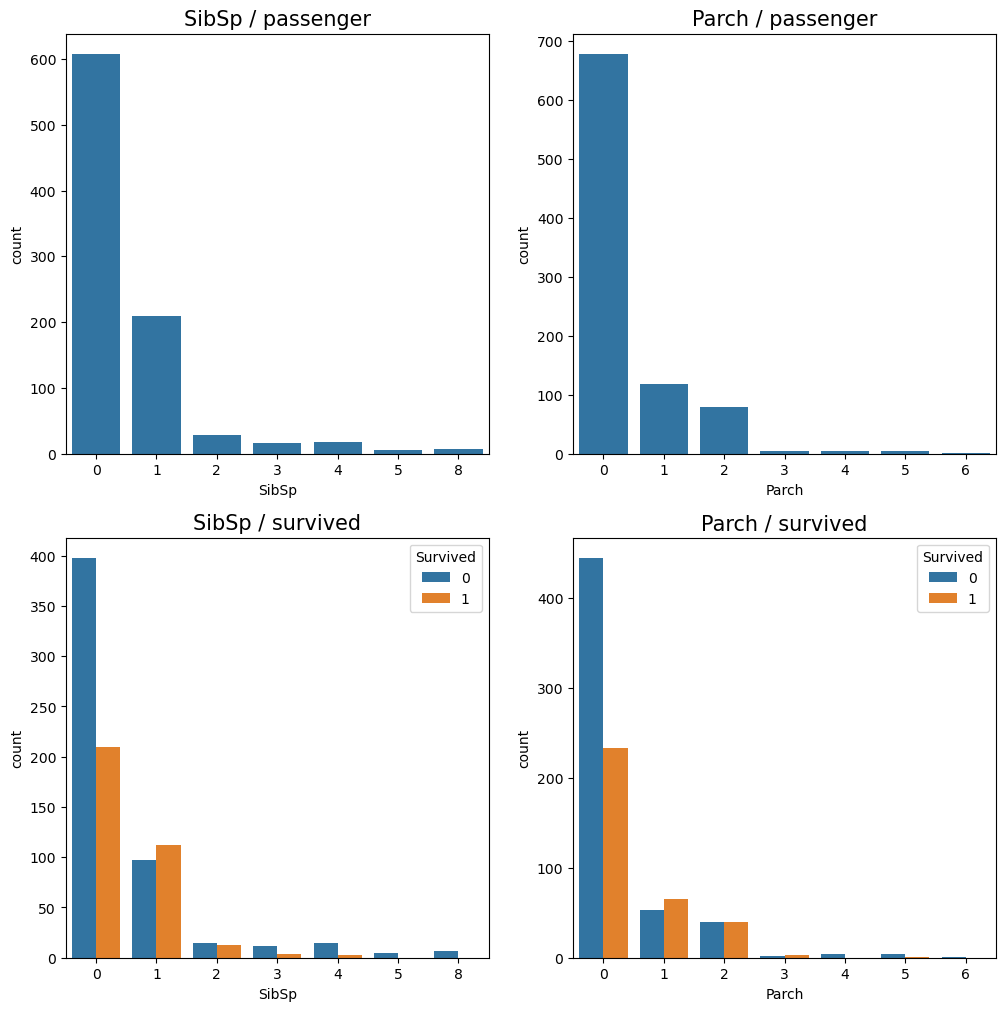

In [31]:
# 이번엔 2 * 2 상자를 만들어서 그래프를 그릴껀데
# 코드상 2 * 2 상자를 한 번 만들어보세요 변수도 생각하셔야 합니다

# 첫번째 박스 만들었다
fig, axes = plt.subplots(2,2,figsize=(12,12))
axes[0][0].set_title('SibSp / passenger', size = 15)
sns.countplot(x = 'SibSp', data = train, ax = axes[0][0])

# 두번째 박스 [0][1]
axes[0][1].set_title('Parch / passenger', size = 15)
sns.countplot(x = 'Parch', data = train, ax = axes[0][1])

# 세번째 박스 [1][0]

axes[1][0].set_title('SibSp / survived', size = 15)
sns.countplot(x = 'SibSp', data = train, hue = 'Survived',ax = axes[1][0])

# 세번째 박스 [1][1]
axes[1][1].set_title('Parch / survived', size = 15)
sns.countplot(x = 'Parch', data = train, hue = 'Survived',ax = axes[1][1])

# SibSp -> 함께 탑승한 형제자매, 배우자의 수 총합 
# Parch -> 함께 탑승한 부모, 자녀 수 총합

### 혼자 탑승한 탑승객이 많다
### 생존 여부를 확인해보면 혼자 탑승한 사람들이 많이 사망한 걸 확인할 수 있다

In [33]:
# 실제로 SibSp Parch별로 생존률을 확인해보자

In [34]:
print(train[['SibSp','Survived']].groupby(['SibSp']).mean())
print(train[['Parch','Survived']].groupby(['Parch']).mean())

       Survived
SibSp          
0      0.345395
1      0.535885
2      0.464286
3      0.250000
4      0.166667
5      0.000000
8      0.000000
       Survived
Parch          
0      0.343658
1      0.550847
2      0.500000
3      0.600000
4      0.000000
5      0.200000
6      0.000000


### 수치적으로 봤을 때 혼자 탑승한 승객의 살 확률이 30% 이며 1~2명 같이 온 사람들의 생존확률이 50% 언저리 인 걸 확인할 수 있다

# 탑승항구

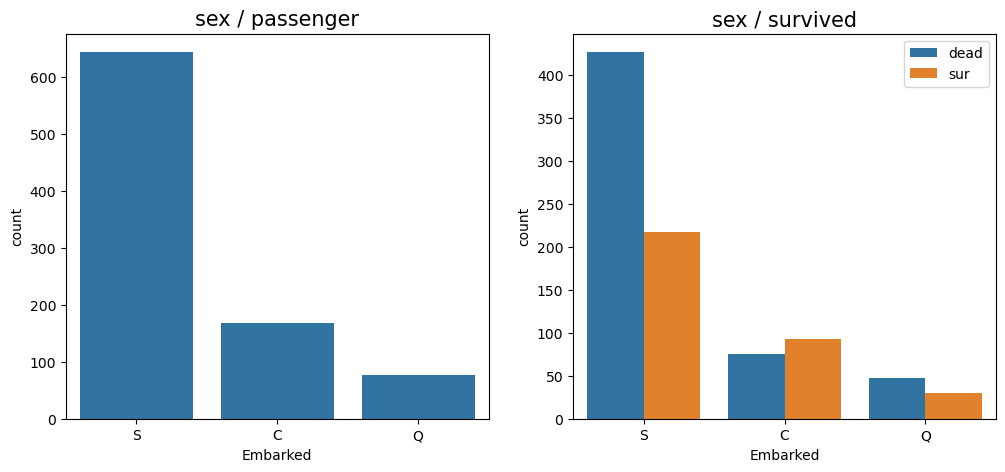

In [37]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

axes[0].set_title('sex / passenger', size = 15)
sns.countplot(x = 'Embarked', data = train, ax = axes[0])

axes[1].set_title('sex / survived', size = 15)
sns.countplot(x = 'Embarked',hue = 'Survived',data = train, ax = axes[1])
axes[1].legend(labels = ['dead','sur'])

### s항구 탑승객이 가장 많은 인원 분포를 가지고 있으며 사망한 인원도 s항구 탑승객이 많다

In [39]:
# 그럼 항구별 사망 비율을 한번 만들어보세요!!
train[['Embarked','Survived']].groupby(['Embarked']).mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


### 항구별로 사망률에 차이가 왜 나는지 확인하기 위해 항구별 탑승객의 티켓 클래스와 동승자 확인해보자

<Axes: >

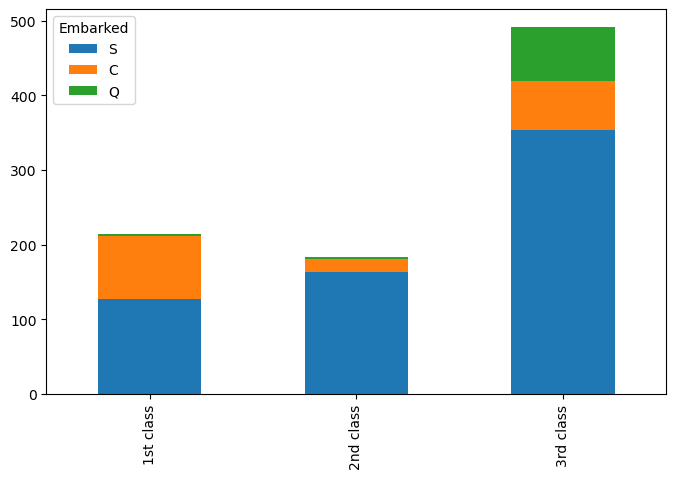

In [41]:
pc1= train[train['Pclass'] == 1]['Embarked'].value_counts()
pc2= train[train['Pclass'] == 2]['Embarked'].value_counts()
pc3= train[train['Pclass'] == 3]['Embarked'].value_counts()

# pc라는 변수에 pc1,pc2,pc3를 데이터 프레임으로 만들어보자
pc = pd.DataFrame([pc1,pc2,pc3])

pc.index = ['1st class','2nd class','3rd class']

# 시각화 해서보면
fig, ax = plt.subplots(figsize = (8,5))
pc.plot(kind = 'bar', stacked = True, ax = ax)

### 3등석(이코노미)에 s항구 탑승객이 주로 분포하고 있는 걸 확인
### 3등석이 배의 하부에 가장 근접했고 class에 따라 생존 확률이 달라지는 걸 확인할 수 있다

### 항구별 탑승객들의 동승자

<Axes: xlabel='Parch', ylabel='count'>

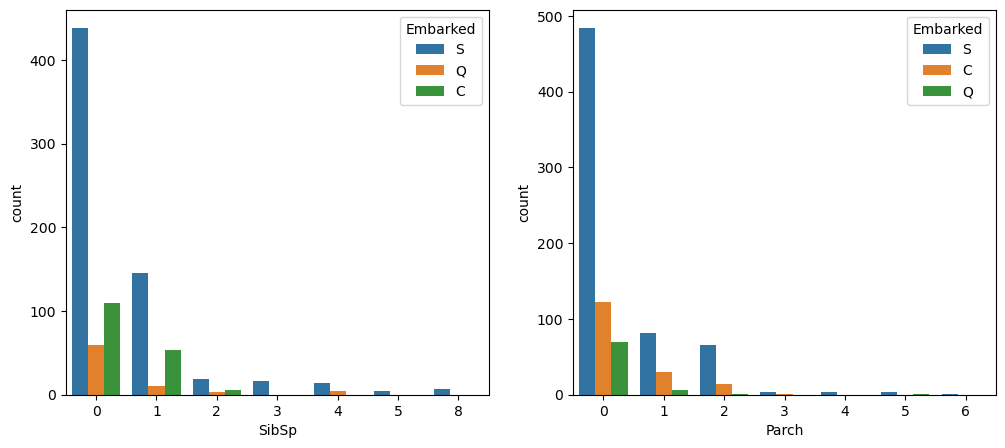

In [44]:
# 항구별 탑승객 동승자에 대해서 알아보도록 하겠습니다
# SibSp, Parch 데이터를 활용해서 확인

fig, ax = plt.subplots(1,2,figsize=(12,5))
sns.countplot(x='SibSp', data = train, hue = 'Embarked', ax = ax[0])
sns.countplot(x='Parch', data = train, hue = 'Embarked', ax = ax[1])

### 혼자 탑승한 탑승객의 수는 S항구에서 탑승객이 압도적으로 많다는 걸 알 수 있다

# Fare(탑승 금액)

<Axes: xlabel='Fare', ylabel='Density'>

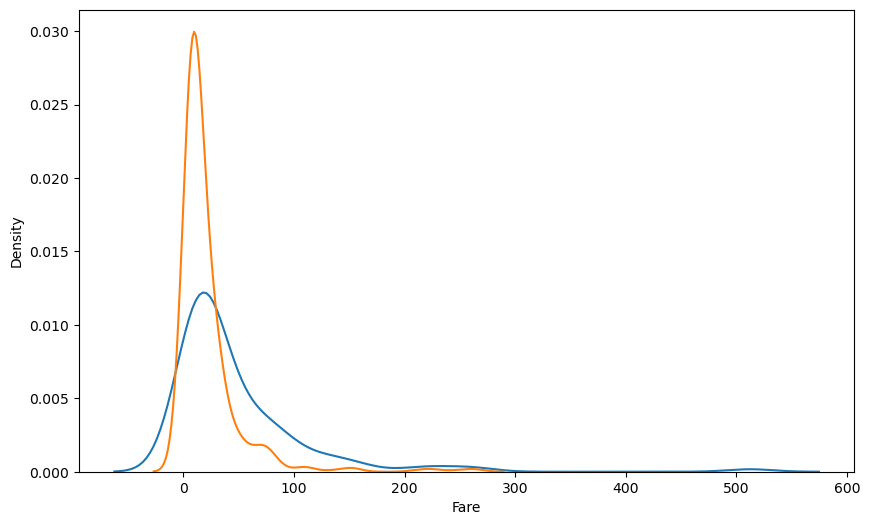

In [47]:
# 탑승 금액의 분포를 확인
fig, ax = plt.subplots(figsize=(10,6))
sns.kdeplot(train[train['Survived'] == 1]['Fare'], ax = ax)
sns.kdeplot(train[train['Survived'] == 0]['Fare'], ax = ax)

### 이 그래프에서 알 수 있는 사실
### 탑승 금액이 적은 쪽은 사망률이 높아 보인다
### 탑승 class / 탑승 금액에 따라 생존 여부에 영향일 미치는 것 같다

### 이번 시간에는 파악한 정보를 토대로 전처리를 진행해보자

In [50]:
# 다시 한 번 결측치 확인
train.isnull().sum()
# [Age : 177, Cabin : 682, Embarked : 2]

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [51]:
# train과 test를 한번에 변환해주기 위해 하나로 합치자
data_list = [train, test]

In [52]:
# 성별부터 전처리 진행
# data_list를 하나씩 꺼내어 i에 넣어주면서~
# astype('category') : male과 female을 카테고리화 시켜주기
# cat : 카테고리화 된 걸 사용하겠다
# codes : 카테고리화 된 걸 숫자로 변환 시켜주겠다
for i in data_list:
    i['Sex'] = i['Sex'].astype('category').cat.codes

train['Sex'].head()

0    1
1    0
2    0
3    0
4    1
Name: Sex, dtype: int8

### Age 전처리
- 결측치가 177개가 있었다 이걸 어떻게 처리할 지 고민

### 여기서 전체 평균으로 채우지 말고 남성은 남성의 평균
### 여성은 여성의 평균으로 한 번 채워보겠습니다

In [55]:
# 남성의 평균과 여성의 평균을 구하겠습니다
sex_mean = train.groupby('Sex')['Age'].mean()
sex_mean

Sex
0    27.915709
1    30.726645
Name: Age, dtype: float64

In [56]:
# 이걸 확인한 이유는 남성이 뭘로 들어갔는지 확인하기 위해서
# 
print(train['Name'].head(1))
print(train['Sex'].head(1))


0    Braund, Mr. Owen Harris
Name: Name, dtype: object
0    1
Name: Sex, dtype: int8


In [57]:
# age 결측치 처리
for i in data_list:
    i.loc[(i['Sex'] == 0) & (i['Age'].isnull()), 'Age'] = sex_mean[0]
    i.loc[(i['Sex'] == 1) & (i['Age'].isnull()), 'Age'] = sex_mean[1]

train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Age를 카테고리화 시키는 작업을 진행
- 예를 들어 남자와 여자는 0과1이라는 수로 극명하게 나눠지는데
- 나이의 경우 20 ~ 30 까지 사이의 값들이 있다 ex) 21,22,23...
- 그래서 이걸 카테고리화를 진행시켜보자

In [59]:
# 우선 age를 5개 구간으로 나누어 agerange라는 곳에 저장해보자
# 새로운 데이터를 추가할 때 데이터[새로운 변수명]으로 데이터를 넣었다
# pandas에서 제공하는 함수 중에 cut 이라는 함수가 있다 이걸로 5개로 잘라보겠다
train['agerange'] = pd.cut(train['Age'], 5)

# agerange와 생존률에 관련된 걸 구해보자
train[['agerange', 'Survived']].groupby(['agerange']).mean()

C:\Users\User\AppData\Local\Temp\ipykernel_11104\3311754121.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train[['agerange', 'Survived']].groupby(['agerange']).mean()


,Survived
agerange,
"(0.34, 16.336]",0.550000
"(16.336, 32.252]",0.344168
"(32.252, 48.168]",0.404255
"(48.168, 64.084]",0.434783
"(64.084, 80.0]",0.090909


In [60]:
0.34, 16.336 -> 0
16.336, 32.252 -> 1
32.252, 48.168 -> 2
48.168, 64.084 -> 3
64.084, 80.0 -> 4
이 구간을 통해 이런식으로 만들어주겠다

SyntaxError: invalid syntax (97215175.py, line 1)

In [82]:
# for문을 통해서 0,1,2,3,4로 맵핑 시켜주자
for i in data_list:
    i.loc[i['Age'] <= 16, 'Age'] = 0
    i.loc[(i['Age'] > 16) & (i['Age'] <= 32), 'Age'] = 1
    i.loc[(i['Age'] > 32) & (i['Age'] <= 48), 'Age'] = 2
    i.loc[(i['Age'] > 48) & (i['Age'] <= 64), 'Age'] = 3
    i.loc[i['Age'] > 64, 'Age'] = 4

# agerange 제거
train.drop('agerange', axis=1, inplace=True)
train.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,1.0,1,0,A/5 21171,7.25,NaN,S


# name 전처리
- Mr, Mrs, Miss 등 명칭을 뽑을 수 있는데 솔직히 큰 차이가 있는지 모르겠지만 우선 전처리 해보겠다

In [85]:
train['Name'].head(10)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: object

In [87]:
# title이라는 컬럼을 새로 만들어서 전처리 해보자
# [A-Za-z] : 대문자 또는 소문자 중에서 하나를 찾아
# + : 알파뱃 글자들이 여러 개 붙어 있는 단어를 찾아라
# \. : 글자 그대로의 점을 찾아라
train['title'] = train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
train['title'].value_counts()

title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

In [89]:
Mr          517
Miss        182
Mrs         125
Master       40
이 부분이 가장 많이 차지하므로 이거 왜 다른 것들은 other 라는 걸로 바꿔주겠다

SyntaxError: invalid syntax (3201190452.py, line 1)

In [91]:
for i in data_list:
    i['title'] = i['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    i['title'] = i['title'].replace(['Dr','Rev','Mlle','Major','Col','Countess',
                                    'Capt','Ms','Sir','Lady','Mme','Don','Jonkheer'], 'other')

# 카테고리화 시켜주고 수치로 바꿔주는 
    i['title_name'] = i['title'].astype('category').cat.codes

In [93]:
train.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,title,title_name
0,1,0,3,"Braund, Mr. Owen Harris",1,1.0,1,0,A/5 21171,7.25,NaN,S,Mr,2


In [95]:
# 이름별로 생존률을 확인
train[['title','Survived']].groupby(['title']).mean()

,Survived
title,
Master,0.575000
Miss,0.697802
Mr,0.156673
Mrs,0.792000
other,0.444444


In [97]:
# title / name 제거
train.drop(['Name','title'], axis=1, inplace=True)
test.drop(['Name','title'], axis=1, inplace=True)

In [99]:
test.head(1)

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,title_name
0,892,3,1,2.0,0,0,330911,7.8292,NaN,Q,3


# SibSp, Parch를 합쳐보자
- 함께 탑승한 형제자매, 배우자의 총합 / 함께 탑승한 부모, 자녀의 총합
- 혼자 탑승한 탑승객과 그 외의 탑승객들의 사망률에 차이가 있었으므로 가족이라는 새로운 컬럼을 만들어보자

In [102]:
train['Family'] = train['SibSp'] + train['Parch'] + 1
test['Family'] = test['SibSp'] + test['Parch'] + 1
train.head(1)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,title_name,Family
0,1,0,3,1,1.0,1,0,A/5 21171,7.25,NaN,S,2,2


<Axes: xlabel='Family', ylabel='count'>

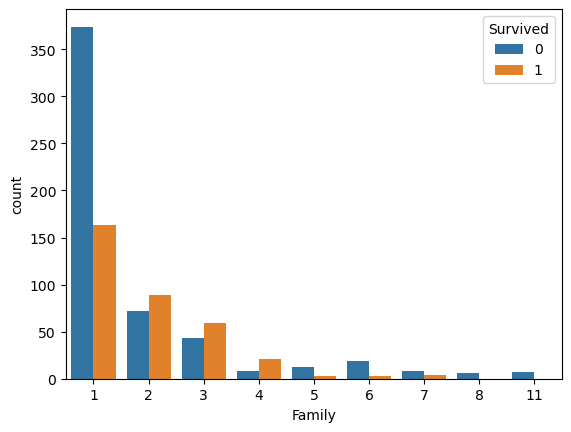

In [104]:
# 피벗테이블을 통해서 가족수별 생존률 확인
pd.pivot_table(train, index = 'Family', values = 'Survived')
sns.countplot(x = 'Family', data = train, hue = 'Survived')

In [106]:
# Famaily라는 컬럼을 만들었으니 SibSp	Parch 드랍하겠다
drop_list = ['SibSp', 'Parch']

for i in data_list:
    i.drop(drop_list, inplace=True, axis=1)

In [108]:
test.head(1)

,PassengerId,Pclass,Sex,Age,Ticket,Fare,Cabin,Embarked,title_name,Family
0,892,3,1,2.0,330911,7.8292,NaN,Q,3,1


# 탑승항구

In [111]:
# value count를 통해서 갯수를 확인해보자
train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

<Axes: xlabel='Embarked', ylabel='count'>

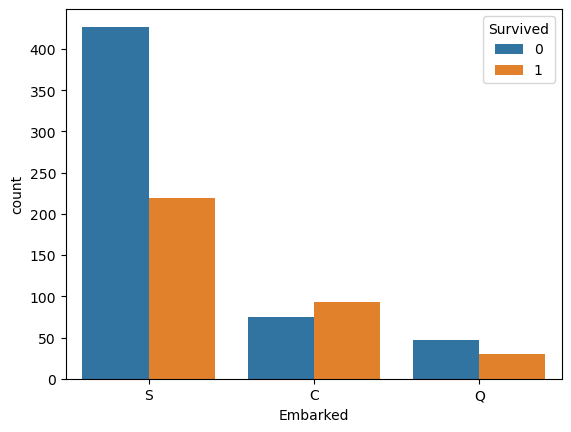

In [113]:
# 결측치 처리
for i in data_list:
    i['Embarked'] = i['Embarked'].fillna('S')
sns.countplot(x = 'Embarked', data = train, hue = 'Survived')

In [115]:
# S / C / Q를 0 1 2로 매핑 시켜주자
mapping = {'S' : 0, 'C' : 1, 'Q' : 2}

for i in data_list:
    i['Embarked'] = i['Embarked'].map(mapping)

In [117]:
train['Embarked'].value_counts()

Embarked
0    646
1    168
2     77
Name: count, dtype: int64

# Cabin : 객실 번호

In [120]:
train['Cabin'].isnull().sum()

687

### 결측값을 N or 다른 알파벳으로 바꿔 맵핑하는 방법이 있으나
### 결측이 너무 많으니 드랍하는 것도 방법이다

In [125]:
# 그러면 여러 분들이 data_list에 있는 cabin을 drop 해주세요
for i in data_list:
    i.drop('Cabin', inplace=True, axis=1)

In [127]:
train.head(1)

,PassengerId,Survived,Pclass,Sex,Age,Ticket,Fare,Embarked,title_name,Family
0,1,0,3,1,1.0,A/5 21171,7.25,0,2,2


# Fare(탑승요금)
- 탑승요금에 구간을 4개로 나눠서 적용시켜주세요

In [131]:
# train과 test에 둘 다 적용을 시켜주기 위해서 data_list를 활용
for i in data_list:
    i['Farerange'] = pd.cut(i['Fare'], 4)

# 구간에 대한 걸 확인
train[['Farerange','Survived']].groupby(['Farerange']).mean()

C:\Users\User\AppData\Local\Temp\ipykernel_11104\221307437.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train[['Farerange','Survived']].groupby(['Farerange']).mean()


,Survived
Farerange,
"(-0.512, 128.082]",0.368113
"(128.082, 256.165]",0.724138
"(256.165, 384.247]",0.666667
"(384.247, 512.329]",1.000000


In [ ]:
(-0.512, 128.082]	0.368113
(128.082, 256.165]	0.724138
(256.165, 384.247]	0.666667
(384.247, 512.329]	1.000000

In [133]:
for i in data_list:
    i.loc[i['Fare'] <= 128, 'Fare'] = 0
    i.loc[(i['Fare'] > 128) & (i['Fare'] <= 256), 'Fare'] = 1
    i.loc[(i['Fare'] > 256) & (i['Fare'] <= 384), 'Fare'] = 2
    i.loc[i['Fare'] > 384, 'Fare'] = 3

,PassengerId,Survived,Pclass,Sex,Age,Ticket,Fare,Embarked,title_name,Family,Farerange
0,1,0,3,1,1.0,A/5 21171,0.0,0,2,2,"(-0.512, 128.082]"
1,2,1,1,0,2.0,PC 17599,0.0,1,3,2,"(-0.512, 128.082]"
2,3,1,3,0,1.0,STON/O2. 3101282,0.0,0,1,1,"(-0.512, 128.082]"
3,4,1,1,0,2.0,113803,0.0,0,3,2,"(-0.512, 128.082]"
4,5,0,3,1,2.0,373450,0.0,0,2,1,"(-0.512, 128.082]"


In [135]:
train['Fare'].value_counts()

Fare
0.0    853
1.0     29
2.0      6
3.0      3
Name: count, dtype: int64

In [137]:
for i in data_list:
    i.drop('Farerange', inplace=True, axis=1)

In [139]:
train.head(1)

,PassengerId,Survived,Pclass,Sex,Age,Ticket,Fare,Embarked,title_name,Family
0,1,0,3,1,1.0,A/5 21171,0.0,0,2,2


In [141]:
drop_list = ['PassengerId','Ticket']
for i in data_list:
    i.drop(drop_list, inplace=True, axis=1)

In [145]:
train.head(1)

,Survived,Pclass,Sex,Age,Fare,Embarked,title_name,Family
0,0,3,1,1.0,0.0,0,2,2


In [149]:
train.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age           0
Fare          0
Embarked      0
title_name    0
Family        0
dtype: int64

In [151]:
test.isnull().sum()

Pclass        0
Sex           0
Age           0
Fare          1
Embarked      0
title_name    0
Family        0
dtype: int64

In [157]:
test['Fare'] = test['Fare'].fillna(0)

In [159]:
test.isnull().sum()

Pclass        0
Sex           0
Age           0
Fare          0
Embarked      0
title_name    0
Family        0
dtype: int64

In [161]:
train.corr()

,Survived,Pclass,Sex,Age,Fare,Embarked,title_name,Family
Survived,1.000000,-0.338481,-0.543351,-0.043800,0.147466,0.106811,-0.052471,0.016639
Pclass,-0.338481,1.000000,0.131900,-0.358769,-0.298580,0.045702,-0.195910,0.065997
Sex,-0.543351,0.131900,1.000000,0.070220,-0.114771,-0.116569,0.040484,-0.200988
Age,-0.043800,-0.358769,0.070220,1.000000,0.063220,-0.051334,0.427999,-0.217063
Fare,0.147466,-0.298580,-0.114771,0.063220,1.000000,0.047596,-0.044644,0.098769
Embarked,0.106811,0.045702,-0.116569,-0.051334,0.047596,1.000000,-0.081928,-0.080281
title_name,-0.052471,-0.195910,0.040484,0.427999,-0.044644,-0.081928,1.000000,-0.207530
Family,0.016639,0.065997,-0.200988,-0.217063,0.098769,-0.080281,-0.207530,1.000000
